In [1]:
import time

import jax
import jax.numpy as jnp

import matplotlib.pyplot as plt

import numpy as np

from scipy.integrate import odeint

In [2]:
import sys
sys.path.append("../..")

from lunanav.estimation.ekf import EkfParams, ekf_predict
from lunanav.sim.simulator import SimParams
from lunanav.sim.math.rigid_body import RigidBody

In [3]:
stationary_pose = np.array([1,2,3,0,0,0,1,0,0,0,0,0,0])


sim = SimParams(
    state0=stationary_pose,
    dt=0.1,
    body=RigidBody(
        mass_kg=100.0,
        I=np.eye(3)*10.0
    ),
)

In [4]:
n = 100

Q = np.eye(13) * 0.01


mu_arr = np.zeros((n, 13))
Sigma_arr = np.zeros((n, 13, 13))

mu_arr[0] = stationary_pose
Sigma_arr[0] = np.eye(13) * 1e-3

for i in range(n-1):
    force, torque = np.zeros(3), np.zeros(3)
    accel = np.zeros(3)
    gyro = np.zeros(3)
    mu_pred, Sigma_pred = ekf_predict(mu_arr[i], Sigma_arr[i], accel, gyro, Q, sim)

    mu_arr[i+1] = mu_pred
    Sigma_arr[i+1] = Sigma_pred

[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1.]


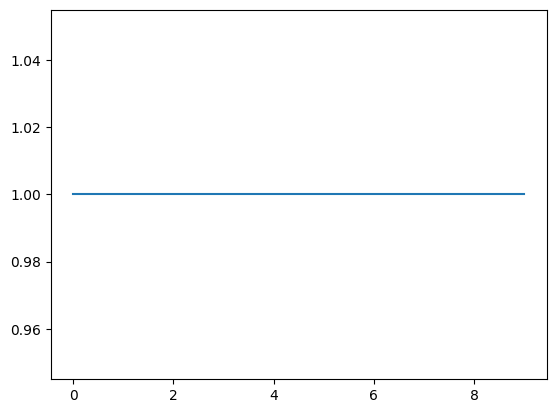

In [6]:
plt.plot(mu_arr[:10,0])

print(mu_arr[:,0])

